# W4A16 dequant-fused matmul kernel — Colab walkthrough

4-bit group-wise quantized weights + fp16 activations, with a fused dequant→GEMM Triton kernel (primary) and an optional CUDA SIMT kernel (stretch).

**Before running:** `Runtime > Change runtime type > T4 GPU`, and make sure the `w4a16-kernel` folder is present in this Colab session (upload it, mount Drive, or `!git clone` your repo).

Runs top-to-bottom: setup → quant demo → correctness → benchmarks → plots → results table → (stretch) CUDA.

## M0 — setup & capability probe

In [1]:
# Colab ships torch + triton already; install only the light extras.
!pip install -q numpy matplotlib pytest

In [3]:
import os
if not os.path.isdir('/content/W4A16-dequant-fused-matmul-kernel'):
    !git clone https://github.com/HamzaImtiaz03/W4A16-dequant-fused-matmul-kernel.git
%cd /content/W4A16-dequant-fused-matmul-kernel
print("cwd:", os.getcwd())
print("top-level:", sorted(os.listdir('.')))
print("src/w4a16 present:", os.path.isdir('src/w4a16'))

Cloning into 'W4A16-dequant-fused-matmul-kernel'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 29 (delta 0), reused 29 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 30.24 KiB | 10.08 MiB/s, done.
/content/W4A16-dequant-fused-matmul-kernel
cwd: /content/W4A16-dequant-fused-matmul-kernel
top-level: ['.git', 'W4A16_SPEC.md', 'w4a16-kernel']
src/w4a16 present: False


In [4]:
%cd w4a16-kernel

/content/W4A16-dequant-fused-matmul-kernel/w4a16-kernel


In [5]:
!bash scripts/setup_colab.sh

 W4A16 kernel — Colab setup
[1/3] Installing lightweight extras (numpy / matplotlib / pytest)...
[2/3] nvidia-smi:
Sat Jun 20 07:05:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                        

In [6]:
!python -m pytest tests/test_quant.py -q
!python -m pytest tests/test_correctness.py -q -k "not cuda"

.......................                                                  [100%]
23 passed in 0.94s
...........................                                              [100%]
27 passed, 8 deselected in 68.00s (0:01:08)


In [7]:
import sys, os

# Locate the repo and put src/ on the path.
CANDIDATES = ['w4a16-kernel', '.', '/content/w4a16-kernel']
SRC = None
for base in CANDIDATES:
    p = os.path.join(base, 'src', 'w4a16', '__init__.py')
    if os.path.exists(p):
        SRC = os.path.abspath(os.path.join(base, 'src'))
        break
assert SRC, 'Could not find w4a16-kernel/src — upload or git clone the repo into Colab first.'
sys.path.insert(0, SRC)
REPO = os.path.dirname(SRC)
print('repo:', REPO)

import torch
print('torch :', torch.__version__, '| cuda build:', torch.version.cuda)
try:
    import triton; print('triton:', triton.__version__)
except Exception as e:
    print('triton import failed:', e)

assert torch.cuda.is_available(), 'No GPU! Runtime > Change runtime type > T4 GPU.'
print('device:', torch.cuda.get_device_name(0))
print('capability:', torch.cuda.get_device_capability(0))
print('bf16 supported:', torch.cuda.is_bf16_supported(), '(T4 = False; we use fp16 + fp32 accumulate)')

repo: /content/W4A16-dequant-fused-matmul-kernel/w4a16-kernel
torch : 2.11.0+cu128 | cuda build: 12.8
triton: 3.6.0
device: Tesla T4
capability: (7, 5)
bf16 supported: True (T4 = False; we use fp16 + fp32 accumulate)


## M1 — quantization + packing demo

In [8]:
import torch
from w4a16 import quantize_weight, dequantize_weight, pack_int4, unpack_int4

torch.manual_seed(0)
K, N, G = 4096, 4096, 128
W = torch.randn(K, N, dtype=torch.float16, device='cuda')
qweight, scales, zeros = quantize_weight(W, G)
print('qweight:', tuple(qweight.shape), qweight.dtype, '(packed int4, ~4x smaller than fp16 W)')
print('scales :', tuple(scales.shape), scales.dtype)
print('zeros  :', tuple(zeros.shape), zeros.dtype)

# pack/unpack roundtrip on random uint4
r = torch.randint(0, 16, (256, 64), dtype=torch.int32, device='cuda')
assert torch.equal(unpack_int4(pack_int4(r)), r)
print('pack/unpack roundtrip: OK')

# quantize -> dequantize error
W_dq = dequantize_weight(qweight, scales, zeros, G)
rel = (W_dq.float() - W.float()).abs().mean() / W.float().abs().mean()
print(f'mean relative quant error: {rel.item()*100:.2f}%')

fp16_bytes = K*N*2
packed_bytes = qweight.numel()*4 + scales.numel()*2 + zeros.numel()*2
print(f'weight bytes: fp16={fp16_bytes/1e6:.1f} MB  packed={packed_bytes/1e6:.1f} MB  ({fp16_bytes/packed_bytes:.2f}x)')

qweight: (512, 4096) torch.int32 (packed int4, ~4x smaller than fp16 W)
scales : (32, 4096) torch.float16
zeros  : (32, 4096) torch.float16
pack/unpack roundtrip: OK
mean relative quant error: 10.84%
weight bytes: fp16=33.6 MB  packed=8.9 MB  (3.76x)


## M3 — correctness: fused Triton kernel == fp32-accumulate oracle

Both sides use the SAME (qweight, scales, zeros), isolating kernel correctness from quantization error. First launch triggers autotune (6 configs).

In [9]:
import torch
from w4a16 import quantize_weight, reference_w4a16, w4a16_matmul

shapes = [(1,4096,4096),(16,4096,11008),(64,11008,4096),(256,4096,4096)]
for (M,K,N) in shapes:
    for G in (64,128):
        X = torch.randn(M,K,dtype=torch.float16,device='cuda')
        W = torch.randn(K,N,dtype=torch.float16,device='cuda')
        qw,s,z = quantize_weight(W,G)
        ref = reference_w4a16(X,qw,s,z,G)
        out = w4a16_matmul(X,qw,s,z,G)
        err = (out.float()-ref.float()).abs().max().item()
        ok = torch.allclose(out,ref,rtol=1e-2,atol=1e-2)
        print(f'M={M:<4} K={K:<6} N={N:<6} G={G:<3} max_abs_err={err:.4f}  {"PASS" if ok else "FAIL"}')
        assert ok, 'kernel != reference'
print('\nAll inline correctness checks passed.')

M=1    K=4096   N=4096   G=64  max_abs_err=0.0625  PASS
M=1    K=4096   N=4096   G=128 max_abs_err=0.0625  PASS
M=16   K=4096   N=11008  G=64  max_abs_err=0.1250  PASS
M=16   K=4096   N=11008  G=128 max_abs_err=0.1250  PASS
M=64   K=11008  N=4096   G=64  max_abs_err=0.2500  PASS
M=64   K=11008  N=4096   G=128 max_abs_err=0.5000  PASS
M=256  K=4096   N=4096   G=64  max_abs_err=0.1250  PASS
M=256  K=4096   N=4096   G=128 max_abs_err=0.2500  PASS

All inline correctness checks passed.


In [10]:
# (Optional) full test suite. Takes a few minutes (autotune over all shapes).
!cd {REPO} && python -m pytest tests/ -q

...........................ssssssss.......................               [100%]
50 passed, 8 skipped in 55.26s


## M4 — benchmarks: latency / TFLOPS / GB/s vs baselines

In [11]:
import sys, os
sys.path.insert(0, os.path.join(REPO, 'benchmarks'))
from bench_gemm import run_sweep, to_markdown_table

results = run_sweep(group_size=128)
print()
print(to_markdown_table(results))

M=1    K=4096   N=4096   | w4a16 0.436ms (0.1 TF, 20 GB/s) | fp16 0.212ms | dq 3.168ms | speedup vs fp16 0.49x, vs dequant 7.26x
M=1    K=4096   N=11008  | w4a16 0.767ms (0.1 TF, 31 GB/s) | fp16 0.543ms | dq 8.358ms | speedup vs fp16 0.71x, vs dequant 10.90x
M=1    K=11008  N=4096   | w4a16 0.862ms (0.1 TF, 28 GB/s) | fp16 0.616ms | dq 8.452ms | speedup vs fp16 0.71x, vs dequant 9.80x
M=64   K=4096   N=4096   | w4a16 1.021ms (2.1 TF, 10 GB/s) | fp16 0.159ms | dq 3.133ms | speedup vs fp16 0.16x, vs dequant 3.07x
M=256  K=4096   N=4096   | w4a16 3.638ms (2.4 TF, 4 GB/s) | fp16 0.266ms | dq 3.338ms | speedup vs fp16 0.07x, vs dequant 0.92x
M=256  K=4096   N=11008  | w4a16 9.622ms (2.4 TF, 3 GB/s) | fp16 1.487ms | dq 8.856ms | speedup vs fp16 0.15x, vs dequant 0.92x
M=256  K=11008  N=4096   | w4a16 10.764ms (2.1 TF, 3 GB/s) | fp16 1.601ms | dq 8.914ms | speedup vs fp16 0.15x, vs dequant 0.83x

| M | K | N | w4a16 (ms) | fp16 (ms) | dequant+mm (ms) | w4a16 TFLOPS | w4a16 GB/s | speedup vs f

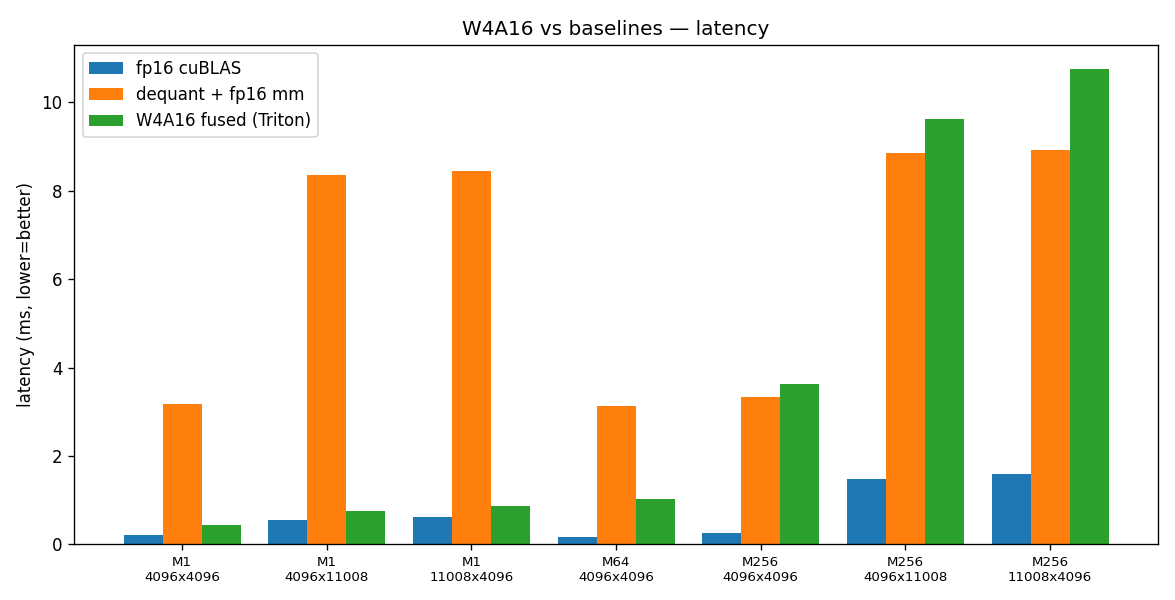

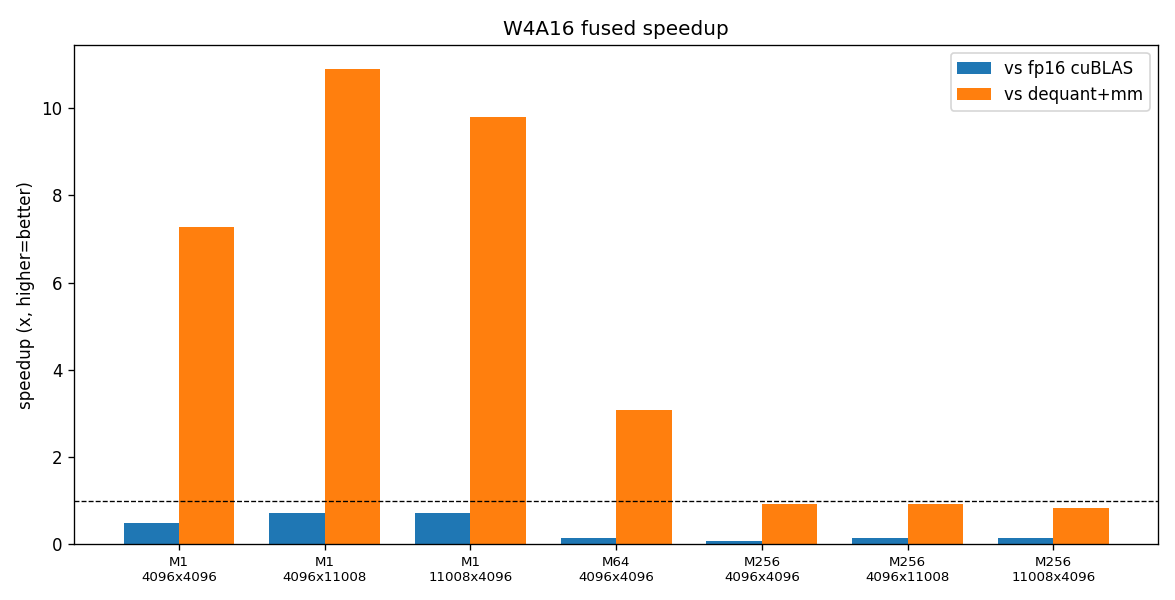

In [12]:
from plot_results import plot_latency, plot_speedup, append_table_to_readme
from IPython.display import Image, display
import os

out_dir = os.path.join(REPO, 'benchmarks', 'plots')
os.makedirs(out_dir, exist_ok=True)
plot_latency(results, os.path.join(out_dir, 'latency.png'))
plot_speedup(results, os.path.join(out_dir, 'speedup.png'))
append_table_to_readme(results)
display(Image(os.path.join(out_dir, 'latency.png')))
display(Image(os.path.join(out_dir, 'speedup.png')))

## M4 — `W4A16Linear` drop-in demo

In [13]:
import torch
from w4a16 import W4A16Linear

lin = torch.nn.Linear(4096, 4096, bias=True).cuda().half()
qlin = W4A16Linear.from_linear(lin, group_size=128)
x = torch.randn(1, 4096, dtype=torch.float16, device='cuda')
y_fp16 = lin(x)
y_w4a16 = qlin(x)
print('fp16 vs W4A16 max abs diff:', (y_fp16.float() - y_w4a16.float()).abs().max().item())
print('(nonzero = 4-bit quantization error, expected)')

fp16 vs W4A16 max abs diff: 0.134765625
(nonzero = 4-bit quantization error, expected)


In [19]:
import os, sys, shutil, subprocess, w4a16

pkg = os.path.dirname(w4a16.__file__)
cuda = os.path.join(pkg, "cuda")
print("package dir:", pkg)
print("cuda dir   :", cuda)
print("cuda files :", os.listdir(cuda) if os.path.isdir(cuda) else "*** MISSING ***")

shutil.rmtree('/root/.cache/torch_extensions', ignore_errors=True)   # force clean rebuild

script = f'''
import os, torch
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"
from torch.utils.cpp_extension import load
m = load(
    name="w4a16_cuda_dbg2",
    sources=[r"{os.path.join(cuda, "bindings.cpp")}", r"{os.path.join(cuda, "w4a16_gemm.cu")}"],
    extra_cuda_cflags=["-O3"], verbose=True,
)
print("BUILD OK")
'''
r = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True)
print("=== STDOUT ===\n" + r.stdout)
print("=== STDERR ===\n" + r.stderr)
print("returncode:", r.returncode)


package dir: /content/W4A16-dequant-fused-matmul-kernel/w4a16-kernel/src/w4a16
cuda dir   : /content/W4A16-dequant-fused-matmul-kernel/w4a16-kernel/src/w4a16/cuda
cuda files : ['w4a16_gemm.cu', 'bindings.cpp']
=== STDOUT ===

=== STDERR ===
Traceback (most recent call last):
  File "<string>", line 5, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py", line 1818, in load
    return _jit_compile(
           ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py", line 2268, in _jit_compile
    _write_ninja_file_and_build_library(
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py", line 2382, in _write_ninja_file_and_build_library
    verify_ninja_availability()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py", line 2448, in verify_ninja_availability
    raise RuntimeError("Ninja is required to load C++ extensions (pip install ninja to get it)")
RuntimeError:

In [23]:
import os, sys, shutil, subprocess, w4a16

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ninja"])
nj = subprocess.run(["ninja", "--version"], capture_output=True, text=True)
print("ninja:", (nj.stdout or nj.stderr).strip() or "NOT FOUND")

pkg = os.path.dirname(w4a16.__file__)
cuda = os.path.join(pkg, "cuda")
shutil.rmtree('/root/.cache/torch_extensions', ignore_errors=True)

script = f'''
import os, torch
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"
from torch.utils.cpp_extension import load
m = load(
    name="w4a16_cuda_dbg3",
    sources=[r"{os.path.join(cuda, "bindings.cpp")}", r"{os.path.join(cuda, "w4a16_gemm.cu")}"],
    extra_cuda_cflags=["-O3"], verbose=True,
)
print("BUILD OK")
'''
r = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True)
print("=== STDOUT ===\n" + r.stdout)
print("=== STDERR ===\n" + r.stderr)
print("returncode:", r.returncode)


ninja: 1.13.0.git.kitware.jobserver-pipe-1
=== STDOUT ===
[1/3] c++ -MMD -MF bindings.o.d -DTORCH_EXTENSION_NAME=w4a16_cuda_dbg3 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -fPIC -std=c++17 -c /content/W4A16-dequant-fused-matmul-kernel/w4a16-kernel/src/w4a16/cuda/bindings.cpp -o bindings.o 
[2/3] /usr/local/cuda/bin/nvcc -MD -MF w4a16_gemm.cuda.o.d -DTORCH_EXTENSION_NAME=w4a16_cuda_dbg3 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=a

In [25]:
import os, torch, w4a16
from torch.utils.cpp_extension import load
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"
pkg = os.path.dirname(w4a16.__file__)
mod = load(name="w4a16_cuda_ext",
           sources=[os.path.join(pkg, "cuda", "bindings.cpp"),
                    os.path.join(pkg, "cuda", "w4a16_gemm.cu")],
           extra_cuda_cflags=["-O3"], verbose=False)

from w4a16 import quantize_weight, reference_w4a16
M, K, N, G = 64, 4096, 4096, 128
X = torch.randn(M, K, dtype=torch.float16, device='cuda')
W = torch.randn(K, N, dtype=torch.float16, device='cuda')
qw, s, z = quantize_weight(W, G)
ref = reference_w4a16(X, qw, s, z, G)
out = mod.w4a16_gemm(X.contiguous(), qw.contiguous(), s.contiguous(), z.contiguous(), G)
print('CUDA max abs err:', (out.float() - ref.float()).abs().max().item())
print('allclose:', torch.allclose(out, ref, rtol=1e-2, atol=1e-2))


CUDA max abs err: 0.125
allclose: False


In [27]:
%cd /content/W4A16-dequant-fused-matmul-kernel
!git pull
import shutil; shutil.rmtree('/root/.cache/torch_extensions', ignore_errors=True)


/content/W4A16-dequant-fused-matmul-kernel
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 13 (delta 6), reused 13 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (13/13), 2.67 KiB | 912.00 KiB/s, done.
From https://github.com/HamzaImtiaz03/W4A16-dequant-fused-matmul-kernel
   69c48e5..78c6579  main       -> origin/main
Updating 69c48e5..78c6579
Fast-forward
 w4a16-kernel/notebooks/w4a16_colab.ipynb  | 31 ++-----------------------------
 w4a16-kernel/requirements.txt             |  1 +
 w4a16-kernel/scripts/setup_colab.sh       |  6 ++++--
 w4a16-kernel/src/w4a16/cuda/w4a16_gemm.cu | 13 +++++++++----
 w4a16-kernel/src/w4a16/cuda_kernel.py     | 31 +++++++++++++++----------------
 5 files changed, 31 insertions(+), 51 deletions(-)


In [28]:
import os, torch, w4a16
from torch.utils.cpp_extension import load
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"
pkg = os.path.dirname(w4a16.__file__)
mod = load(name="w4a16_cuda_ext",
           sources=[os.path.join(pkg, "cuda", "bindings.cpp"),
                    os.path.join(pkg, "cuda", "w4a16_gemm.cu")],
           extra_cuda_cflags=["-O3"], verbose=False)

from w4a16 import quantize_weight, reference_w4a16
M, K, N, G = 64, 4096, 4096, 128
X = torch.randn(M, K, dtype=torch.float16, device='cuda')
W = torch.randn(K, N, dtype=torch.float16, device='cuda')
qw, s, z = quantize_weight(W, G)
ref = reference_w4a16(X, qw, s, z, G)
out = mod.w4a16_gemm(X.contiguous(), qw.contiguous(), s.contiguous(), z.contiguous(), G)
print('CUDA max abs err:', (out.float() - ref.float()).abs().max().item())
print('allclose:', torch.allclose(out, ref, rtol=1e-2, atol=1e-2))


CUDA max abs err: 0.125
allclose: True
